**Проект: Разведывательный анализ данных**

Датасет:  
https://www.kaggle.com/datasets/kemical/kickstarter-projects?resource=download

**Постановка задачи**   
Построить модели, предсказывающие, будет ли проект успешен на кикстартере или нет, сравнить их эффективность, понять, какие признаки определяют успех проекта  

Задача состоит в бинарной классификации, целевая переменная  -  state, то есть статус проекта

In [2]:
import pandas as pd
import numpy as np

In [3]:

df = pd.read_csv("/content/drive/MyDrive/ks-projects-201801.csv")
df.head()


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [4]:
df.columns

Index(['ID', 'name', 'category', 'main_category', 'currency', 'deadline',
       'goal', 'launched', 'pledged', 'state', 'backers', 'country',
       'usd pledged', 'usd_pledged_real', 'usd_goal_real'],
      dtype='object')

**Описание признаков**  
ID - айди проекта на кикстартере  
name - название проекта  
category - категория  
main_category - категория компании  
currency - валюта, используемая в сборе  
deadline - крайний срок краундфаудинга  
goal - сумма денег, необходимое автору проекта  
launched - дата запуска  
pledged - собранная сумма денег  
state - нынешний статус компании, целевая переменная  
backers - количество спонсоров  
country - страна проекта  
usd pledged - собрано в USD  
usd_pledged_real - реально собрано в USD  
usd_goal_real - цель в USD

**Анализ признаков**  
ID не влияет на предсказание, поэтому его можно сразу откинуть

по name можно сделать предположение, что короткое название имеет большую привлекательность, чем длинное, а также, что чем меньше слов в названии, тем лучше, так что преобразуем этот признак в 2 новых, в длинну названия и количество слов

pledged, backers, usd pledged и usd_pledged_real нельзя использовать, ведь это данные, полученные уже после запуска проекта  

goal и usd_goal_real по факту обозначают одно и то же, только первое в разных валютах, а второе в долларах, поэтому логичнее использовать только usd_goal_real, ведь оно уже приведено к общему виду  

в итоге остаются category, main_category, currency, deadline, launched, state, country и usd_goal_real

In [5]:
df = df.drop(columns = [
    "ID",
    "pledged",
    "backers",
    "usd pledged",
    "usd_pledged_real",
    "goal"
])

In [6]:
df["name_length"] = df["name"].astype(str).apply(len)
df["name_word_count"] = (
    df["name"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

Можем преобразовать дедлайн и дату запуска в более понятные признаки, в количество дней, выделенных на сбор средств, а также учесть, в какой день недели, месяц и год он был запущен, возможно это имеет значение

In [7]:
df["launched"] = pd.to_datetime(df["launched"])
df["deadline"] = pd.to_datetime(df["deadline"])

df["duration_days"] = (
    df["deadline"] - df["launched"]
).dt.days

df["launch_weekday"] = df["launched"].dt.day_name()
df["launch_month"] = df["launched"].dt.month_name()
df["launch_year"] = df["launched"].dt.year

df = df.drop(columns=["launched", "deadline", "name"])

Так как цель по финансированию имеет слишком огромный разброс вправо, будем использовать логарифм цели

In [8]:
df["goal_log"] = np.log1p(df["usd_goal_real"])

In [9]:
print("Размер объединенного датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

df.info()

Размер объединенного датасета: (378661, 13)
Количество строк: 378661
Количество столбцов: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   category         378661 non-null  object 
 1   main_category    378661 non-null  object 
 2   currency         378661 non-null  object 
 3   state            378661 non-null  object 
 4   country          378661 non-null  object 
 5   usd_goal_real    378661 non-null  float64
 6   name_length      378661 non-null  int64  
 7   name_word_count  378661 non-null  int64  
 8   duration_days    378661 non-null  int64  
 9   launch_weekday   378661 non-null  object 
 10  launch_month     378661 non-null  object 
 11  launch_year      378661 non-null  int32  
 12  goal_log         378661 non-null  float64
dtypes: float64(2), int32(1), int64(3), object(7)
memory usage: 36.1+ MB


In [10]:
summary_table = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean()
}).sort_values("missing_count", ascending=False)

summary_table

,dtype,n_unique,missing_count,missing_share
category,object,159,0,0.0
main_category,object,15,0,0.0
currency,object,14,0,0.0
state,object,6,0,0.0
country,object,23,0,0.0
usd_goal_real,float64,50339,0,0.0
name_length,int64,96,0,0.0
name_word_count,int64,23,0,0.0
duration_days,int64,99,0,0.0
launch_weekday,object,7,0,0.0


Как видно пропущенных признаков нет

Так как предсказываем успех проекта, в state оставим только failed и succesful и предадим им числовые значения 0 и 1

In [12]:
df = df[df["state"].isin([
    "successful",
    "failed"
])]

df["state"] = df["state"].map({
    "successful": 1,
    "failed": 0
})

In [13]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

df[numeric_cols].describe().T

Числовые признаки: ['state', 'usd_goal_real', 'name_length', 'name_word_count', 'duration_days', 'goal_log']
Категориальные признаки: ['category', 'main_category', 'currency', 'country', 'launch_weekday', 'launch_month']


,count,mean,std,min,25%,50%,75%,max
state,331675.0,0.403877,4.906742e-01,0.00000,0.000000,0.000000,1.000000,1.000000e+00
usd_goal_real,331675.0,41510.001543,1.108930e+06,0.01000,2000.000000,5000.000000,15000.000000,1.663614e+08
name_length,331675.0,34.220053,1.596171e+01,1.00000,21.000000,33.000000,48.000000,8.500000e+01
name_word_count,331675.0,5.630985,2.757352e+00,1.00000,3.000000,5.000000,8.000000,2.900000e+01
duration_days,331675.0,32.954902,1.271333e+01,0.00000,29.000000,29.000000,35.000000,9.100000e+01
goal_log,331675.0,8.582628,1.667105e+00,0.00995,7.601402,8.517393,9.615872,1.892967e+01


Построение графиков

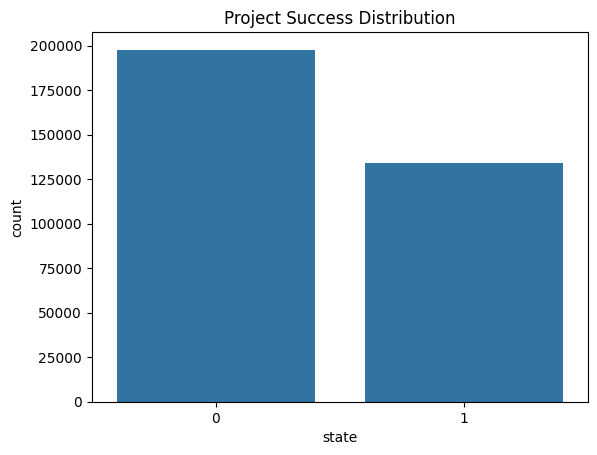

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="state", data=df)

plt.title("Project Success Distribution")
plt.show()

Как видно датасет достаточно сбалансированный по целевой переменной

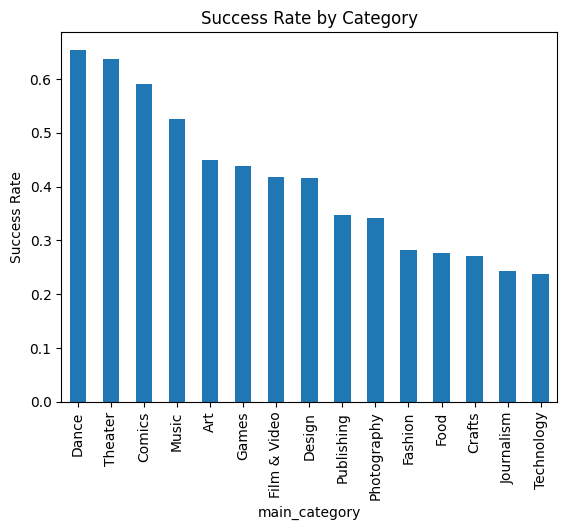

In [15]:
success_by_category = (
    df.groupby("main_category")["state"]
    .mean()
    .sort_values(ascending=False)
)

success_by_category.plot(kind="bar")

plt.title("Success Rate by Category")
plt.ylabel("Success Rate")
plt.show()

Танцы, театр, комиксы и музыка показываеют высокие результаты успеха, что наводит на мысль, что творческие направление имеют больший шанс на успех.  
Технологии, еда, мода, ручное творчество и медиа проекты имеют заметно меньше шансов на успех, это можно обосновать трудностями в производстве, большими ожиданиями и высокими целями по сборам

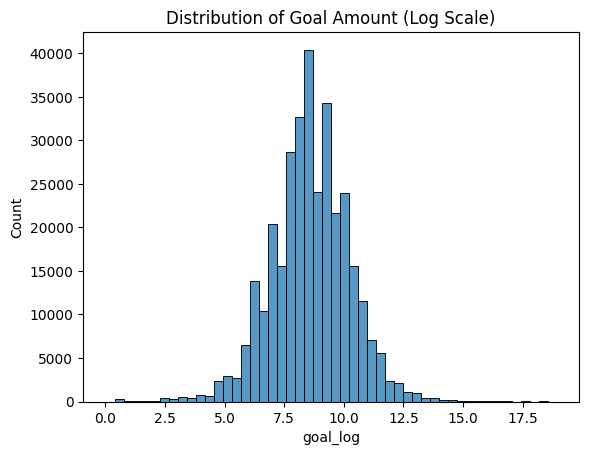

In [16]:
sns.histplot(df["goal_log"], bins=50)

plt.title("Distribution of Goal Amount (Log Scale)")
plt.show()

Видно, что большинство проектов имеют средние цели по финансированию, эктремально дорогих или очень дешевых достаточно мало

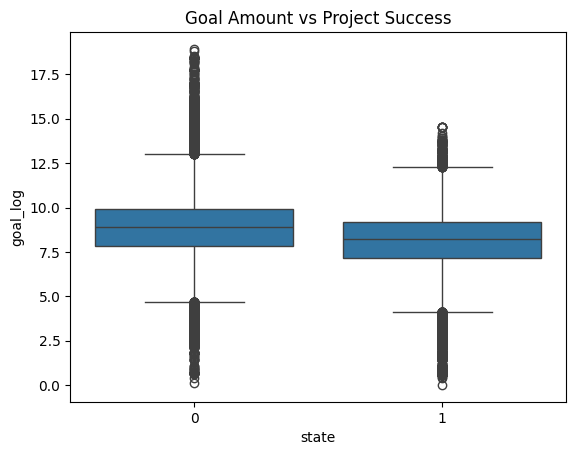

In [17]:
sns.boxplot(x="state", y="goal_log", data=df)

plt.title("Goal Amount vs Project Success")
plt.show()

По этому графику видно, что слишком огромные цели по финансированию приводят к провалу, в среднем же цели провалившихся и успешных проектов находятся на одном уровне

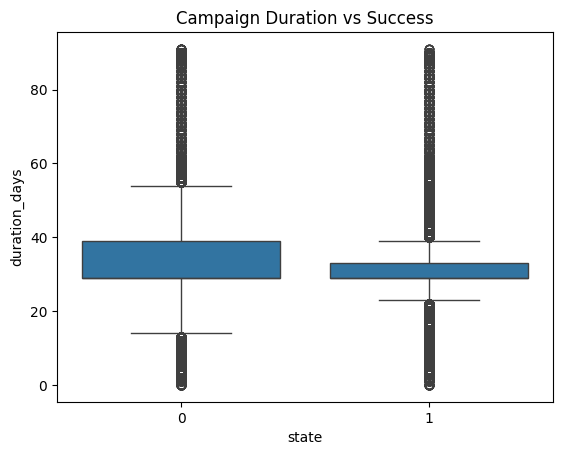

In [18]:
sns.boxplot(x="state", y="duration_days", data=df)

plt.title("Campaign Duration vs Success")
plt.show()

По этому же графику видно, что часто успешные проекты имеют немного меньшую длительность сбора, нежели провалившиеся

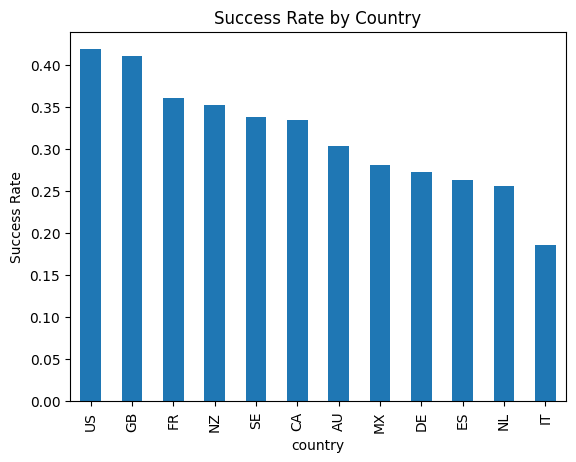

In [26]:
country_stats = df.groupby("country").agg({
    "state": ["mean", "count"]
})

country_stats.columns = ["success_rate", "project_count"]

country_stats = country_stats[
    country_stats["project_count"] > 1000
]

country_stats = country_stats.sort_values(
    "success_rate",
    ascending=False
)

country_stats["success_rate"].plot(kind="bar")

plt.title("Success Rate by Country")
plt.ylabel("Success Rate")
plt.show()

Проекты из США и Великобритании имеют больший шанс на успех, а в Италии заметно низкие, это можно объяснить заинтересованностью населения в стартапах

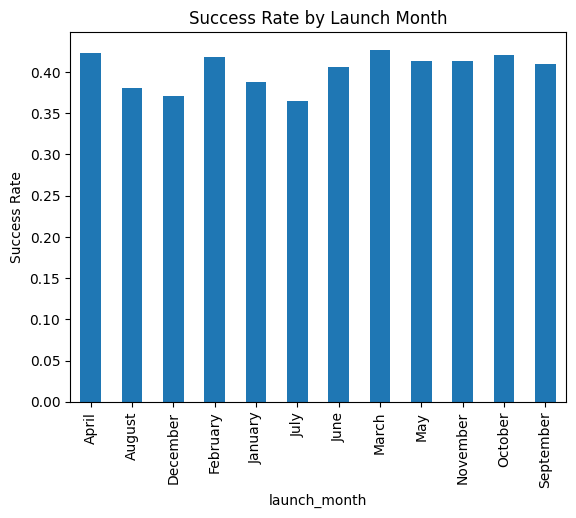

In [20]:
month_success = (
    df.groupby("launch_month")["state"]
    .mean()
)

month_success.plot(kind="bar")

plt.title("Success Rate by Launch Month")
plt.ylabel("Success Rate")
plt.show()

Здесь видно, что проекты, запущенные в августе, декабре, январе и июле проваливаются чаще, чем в другие месяцы. Это может быть связано с сезонной активностью пользователей

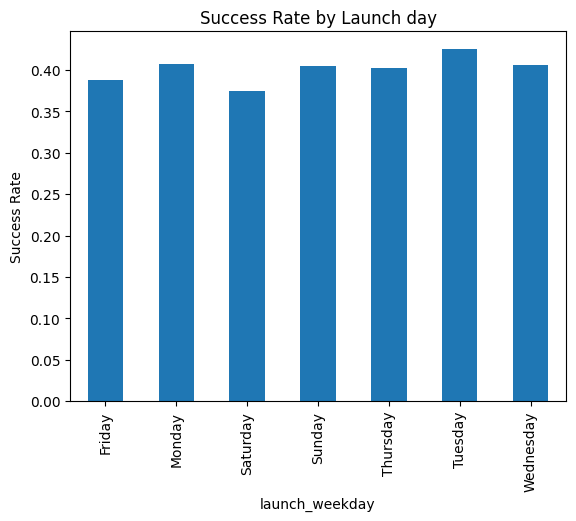

In [21]:
day_success = (
    df.groupby("launch_weekday")["state"]
    .mean()
)

day_success.plot(kind="bar")

plt.title("Success Rate by Launch day")
plt.ylabel("Success Rate")
plt.show()

По дням, в пятницу и субботу шансы уменьшаюся, а во вторник заметно выше остальных, это также можно объяснить тем, что в пятницу и субботу многие хотят отвлечься от суеты и отдохнуть, а вторник - это самый разгар рабочей недели

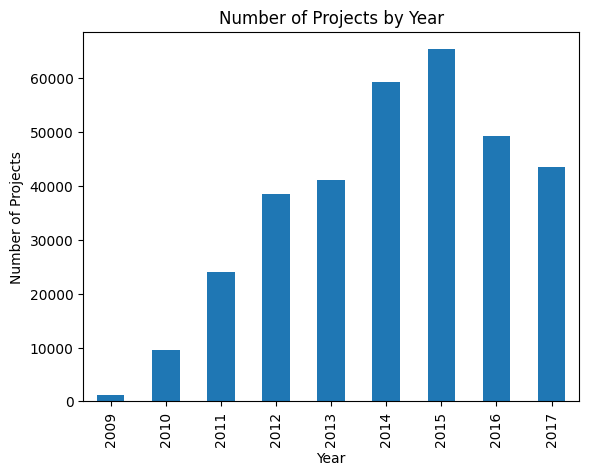

In [27]:
df["launch_year"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Projects by Year")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.show()

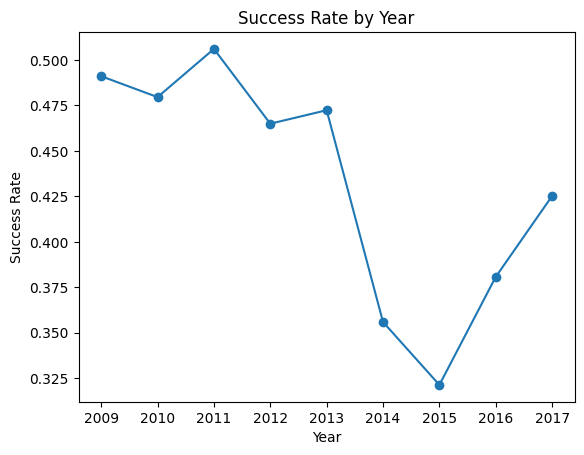

In [28]:
year_success = (
    df.groupby("launch_year")["state"]
    .mean()
)

year_success.plot(marker="o")

plt.title("Success Rate by Year")
plt.ylabel("Success Rate")
plt.xlabel("Year")
plt.show()

В некоторых случаях видна обратная зависимость количества проектов с количеством успешных, например, в 2014 и 2015 годах количество запущенных проектов значительно увеличилось, а количество успешынх сильно просело, это объясняется переполненностью для спонсоров, возможно они не могут сконцентрироваться на чем-то одном, либо же интересные проекты теряются на фоне остальных

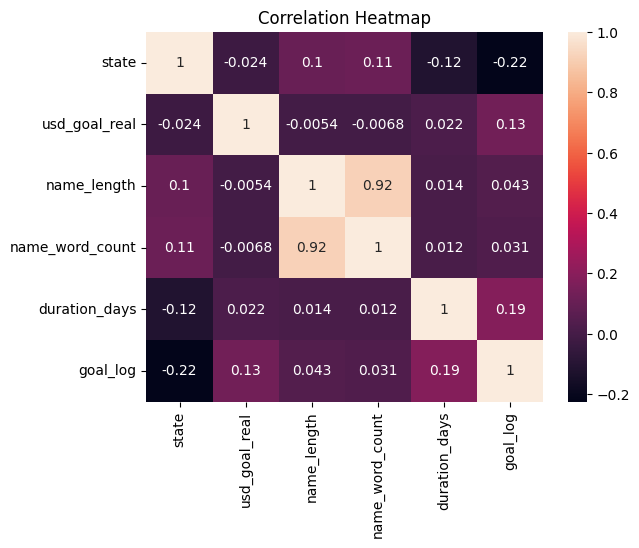

In [22]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Выводы**  
Проведённый EDA позволил выявить значимые закономерности и взаимосвязи между характеристиками Kickstarter-проектов и их итоговым статусом. Анализ показал, что как числовые признаки (например, размер финансирования и длительность кампании), так и категориальные признаки (категория проекта, страна запуска, сезонность) могут оказывать влияние на вероятность успеха проекта. Полученные выводы демонстрируют, что данные обладают достаточной информативностью для построения моделей для предсказания.